# Local에서 실행하기 위한 code
### Colab을 사용하는 경우를 위해 local에서 쉽게 파일을 압축하고 google drive에 보내기 위한 코드
- map_generator.py, environment.py가 잘 작동하는지 확인
- Source code 파일과 훈련을 재개할 model을 압축하여 google drive에 보내는 코드가 작성되어 있음
- Tensorboard server를 열거나 google drive를 wsl과 mount하는 명령어가 적혀있음 -> 이를 Terminal에 적어서 실행

### Python 파일을 검사하기 위한 사전 설정

In [2]:
# Working directory 수정: 압축할 lg_robot 폴더의 위치
# %cd c:\Users\wrlat\Desktop\LCH\LG_robot_DQN
%cd /home/poiuy/lg_robot/

/home/poiuy/lg_robot


In [3]:
# Python 파일 수정 시 자동으로 새로고침
%load_ext autoreload
%autoreload 2

## Python 파일들이 잘 수행되는지 검사

### map_generator.py

In [ ]:
from path_planner.map_generator import generate_map_by_seed_and_visualize
from path_planner.config import EnvConfig

generate_map_by_seed_and_visualize(robot_diameter=EnvConfig().robot_size, seed=128, level=4)

In [1]:
# %cd /home/poiuy/lg_robot/
%cd c:\Users\wrlat\Desktop\LCH\LG_robot_DQN

from path_planner.map_generator import generate_multiple_maps, zip_map_files
from path_planner.config import MAP_SAVE_DIR, EnvConfig, MapConfig

window_size = MapConfig().window_size
for mult in range(1, 5):
    map_size = (window_size*mult, window_size*mult)
    generate_multiple_maps(robot_diameter=EnvConfig().robot_size, 
                           mode="train", 
                           map_num_per_cond=200, 
                           visualize=True, 
                           map_size=map_size)
generate_multiple_maps(robot_diameter=EnvConfig().robot_size, 
                       mode="train", 
                       map_num_per_cond=1000, 
                       visualize=True)
# zip_map_files(zip_file_name='test_map_lch.zip')

c:\Users\wrlat\Desktop\LCH\LG_robot_DQN


In [ ]:
from path_planner.utils.visualizer import visualize_saved_map, visualize_mode_map
from path_planner.config import MAP_SAVE_DIR
from path_planner.map_generator import ObstacleMap
import os

map_file_path = os.path.join(MAP_SAVE_DIR, "test", "test_map_3m3m_level3_07.npy")
visualize_saved_map(map_file_path)
visualize_mode_map(map_file_path)
 
obs_map = ObstacleMap.load_from_file(map_file_path)

### environment.py

In [ ]:
from path_planner.config import EnvConfig, DEFAULT_SEED
from path_planner.environment import get_args, CoverageEnv
from path_planner.utils.map_utils import make_robot_mask
from path_planner.utils.visualizer import visualize_mask
from path_planner.map_layer import MapConfigSchema
import sys

sys.argv = [" ", # 파일명이 없으므로 sys.argv[0]은 공백으로 처리
            # "--robot",
            "--see_map",
            "--see_obs",
            "--debug_reset",
            "--debug_step"]
args = get_args()
cfg = EnvConfig()
env = CoverageEnv(seed=478)

# 0. Robot visualize
if args.robot:
    visualize_mask(make_robot_mask(robot_size=cfg.robot_size))

map_config = MapConfigSchema(level=1, H=40, W=40)
obs, info = env.reset(map_config=map_config)
if args.debug_reset:
    if args.see_map:
        # 1. Map visualize: Agent layer, Cleaned layer, Obstacle layer, Collision map, 
        env.show_visualized_img('layer')
        env.show_visualized_img('traj')
    if args.see_obs:
        # 2. observation visualization
        env.show_visualized_img('obs')

if args.debug_step:
    # 3. step() method
    # action_seq = [0]*150 + [1]*3 + [3]*150 + [2]*250 + [3]*100 + [1]*200
    action_seq = [0]*100 + [7] + [13]
    for action in action_seq:
        obs, reward, terminated, truncated, info = env.step(action)
    if args.see_map:
        # 1. Map visualize: Agent layer, Cleaned layer, Obstacle layer, Collision map, 
        env.show_visualized_img('layer')
        env.show_visualized_img('traj')
    if args.see_obs:
        # 2. observation visualization
        env.show_visualized_img('obs')

## Colab 또는 GPU 이용 서버를 이용하기 위해 압축 파일 생성 

- 압축 파일을 생성하기 전에 아래 명령어를 terminal에 복사해서 암호를 입력하여 G:와 /mnt/g를 연결

In [ ]:
sudo mkdir -p /mnt/g && sudo mount -t drvfs G: /mnt/g

- /mnt/g에 구글 드라이브에 올릴 파일을 옮기면 구글 드라이브에 파일이 업로드 됨.
- 압축 파일은 ~/lg_robot 폴더에 생성되고 이를 구글 드라이브에 복사함
- 압축 파일이 원하는대로 생성되었는지 확인하고 싶으면 local에서 압축 파일을 해제하고 그 내용물을 확인함.
- 압축 파일이 구글 드라이브에 존재하는 것을 확인하면 local에 있는 압축 파일을 제거함.

### 압축 파일 생성

In [ ]:
# 파일을 google drive에 쉽게 올리기 위해 압축하기 위한 코드
# 필요한 파일들만 골라서 압축

import zipfile
import os

def create_custom_project_zip(base_path, src_rel_dir, model_setting, output_zip_name):
    """
    base_path: 최상위 폴더 경로 (예: 'LG_ROBOT')
    include_paths: 압축에 포함할 하위 경로 리스트
    output_zip_name: 생성될 압축 파일 이름
    """
    ############# src에 있는 폴더 중 압축하지 않을 파일을 선정 #############
    exclude_folders_in_srcdir = {'__pycache__', 'logs', 'models'}
    ###################################################################
    
    with zipfile.ZipFile(output_zip_name, 'w', zipfile.ZIP_DEFLATED) as project_zip:
        
        # source code를 압축파일에 추가
        src_abs_dir = os.path.join(base_path, src_rel_dir) # source code가 담긴 폴더 경로
        if os.path.isdir(src_abs_dir):
            for root, dirs, files in os.walk(src_abs_dir):
                
                # dirs에서 탐색하지 않으려는 폴더들을 제외하여 src code만 압축 파일에 저장
                dirs[:] = [d for d in dirs if d not in exclude_folders_in_srcdir]
                
                for src_file in files:
                    src_file_abs_path = os.path.join(root, src_file) # 각 source code의 절대 경로
                    arcname = os.path.relpath(src_file_abs_path, os.path.dirname(base_path)) # zip 파일의 구조를 맞추기 위한 상대 경로
                    project_zip.write(src_file_abs_path, arcname)
                    
        # model file을 압축파일에 추가
        model_rel_dir = model_setting['Model_folder']
        model_abs_dir = os.path.join(base_path, model_rel_dir) # models이 담긴 폴더 경로 
        if os.path.isdir(model_abs_dir):
            
            # Model file을 압축
            model_list = model_setting['Include_models']
            if len(model_list) > 0:
                for model_file in model_list:
                    model_file_abs_path = os.path.join(model_abs_dir, model_file)
                    if os.path.isfile(model_file_abs_path):
                        arcname = os.path.relpath(model_file_abs_path, os.path.dirname(base_path))
                        project_zip.write(model_file_abs_path, arcname)
            
            # Checkpoint 중에 최신 checkpoint를 압축
            checkpoint_list = model_setting['Include_checkpoints']
            if len(checkpoint_list) > 0:
                for checkpnt_fld in checkpoint_list:
                    checkpnt_fld += "_checkpoints" # Checkpoint 폴더 이름
                    checkpnt_fld_abs_path = os.path.join(model_abs_dir, checkpnt_fld)
                    if os.path.isdir(checkpnt_fld_abs_path):
                        all_chkpnt_files = [os.path.join(checkpnt_fld_abs_path, f) for f in os.listdir(checkpnt_fld_abs_path)] # Checkpoint 전체
                        if all_chkpnt_files:
                            latesst_file = max(all_chkpnt_files, key=os.path.getmtime) # 최신 파일을 고름
                            arcname = os.path.relpath(latest_file, os.path.dirname(base_path))
                            project_zip.write(latest_file, arcname)

PROJECT_ROOT = os.getcwd() # 최상위 프로젝트 폴더 경로
SOURCE_CODE_FOLDER = "src/robot_vacuum_redqn/robot_vacuum_redqn" # Source code 폴더

############# 저장할 model을 설정하기 위한 코드: 사용자 설정 가능 #############
# Model을 받기 위한 설정
MODEL_FOLDER = "src/robot_vacuum_redqn/robot_vacuum_redqn/models" # Model 폴더
INCLUDE_MODELS = ["one_map_model.pth"] # models 폴더에 넣고 싶은 model 파일 목록
INCLUDE_CHECKPOINTS = ["one_map_model_-2.0"] # models 폴더에 넣고 싶은 checkpoint 목록 (이름에서 _checkpoints는 쓰지 않고 모델 이름만 씀)
#########################################################################

# 압축파일 이름
ZIP_NAME = "lg_robot_forColab.zip"

# Local에 저장할 경로 설정
LOCAL_OUTPUT_NAME = os.path.join(PROJECT_ROOT, ZIP_NAME)

# 구글 드라이브에 저장할 경로 설정
GDRIVE_PATH = "/mnt/g/내 드라이브" # WSL에서 인식한 구글 드라이브 한글 경로
target_dir = os.path.join(GDRIVE_PATH, "Colab_Uploads") # 구글 드라이브에 업로드할 폴더를 생성
if not os.path.exists(target_dir):
    os.makedirs(target_dir, exist_ok=True)
    print(f"폴더 생성 완료: {target_dir}")
GDRIVE_OUTPUT_NAME = os.path.join(target_dir, ZIP_NAME) # 업로드 경로 설정

model_setting = {
    "Model_folder": MODEL_FOLDER,
    "Include_models": INCLUDE_MODELS,
    "Include_checkpoints": INCLUDE_CHECKPOINTS,
}

# 실행
create_custom_project_zip(PROJECT_ROOT, SOURCE_CODE_FOLDER, model_setting, LOCAL_OUTPUT_NAME)
print(f"압축 완료: {os.path.join(LOCAL_OUTPUT_NAME)}")

# 구글 드라이브에 복사
!cp "{LOCAL_OUTPUT_NAME}" "{GDRIVE_OUTPUT_NAME}"

In [ ]:
# 압축 파일을 해제하고 코드를 실행할 for_colab.ipynb를 drive에 복사
# 드라이브에서 이 파일을 열어서 사용
import os

notebook_src_path = os.path.join(PROJECT_ROOT, SOURCE_CODE_FOLDER, "for_colab.ipynb")
notebook_src_dest = os.path.join("/mnt/g/내 드라이브/Colab_Uploads/", "for_colab.ipynb")
!cp "{notebook_src_path}" "{notebook_src_dest}"

In [ ]:
# 압축 파일이 잘 압축되었는지 확인하기 위한 코드: /lg_robot 폴더에 압축 해제
import zipfile
import os

try: 
    with zipfile.ZipFile(LOCAL_OUTPUT_NAME, 'r') as zip_ref:
        zip_ref.extractall(os.path.dirname(LOCAL_OUTPUT_NAME))
except FileNotFoundError:
    print(f"{LOCAL_OUTPUT_NAME} 파일이 존재하지 않습니다.")
except Exception as e:
    print(f"압축 해제 중 오류 발생: {e}")

In [ ]:
# 압축파일이 구글 드라이브에 잘 복사 되었는지 확인
!ls "/mnt/g/내 드라이브/Colab_Uploads"

In [ ]:
# 압축 파일이 구글 드라이브에 존재하면 local에 있는 압축 파일을 삭제
!rm "{LOCAL_OUTPUT_NAME}"

## TensorBoard 서버 열기
- Terminal을 열어서 아래 명령어를 입력하여 훈련 현황을 볼 수 있도록 함.
- 구글 드라이브에 있는 logs file에 접근하여 tensorboard를 출력함

In [ ]:
tensorboard --logdir="/mnt/g/내 드라이브/Colab_Uploads/lg_robot/src/robot_vacuum_redqn/robot_vacuum_redqn/logs"

- /mnt/g/에 tensorboard update이 잘 일어나지 않으면 구글 드라이브에서 직접 tensorboard 파일을 가져와서 local에 저장
- local에 저장한 tensorboard 파일을 서버에 전송하기 위해 아래 명령어를 terminal에 입력

In [ ]:
tensorboard --logdir="/home/poiuy/lg_robot/src/robot_vacuum_redqn/robot_vacuum_redqn/logs"

### Local에서 파일 실행

In [ ]:
%cd c:\Users\wrlat\Desktop\LCH\LG_robot_DQN

from path_planner.main import main
import sys

args_str = """
    --mode train
    --model_name LSTM_model_change_to_advantage_and_reduce_steps.pth
    --optimizer adam
    --batch_size 32
    --lr 1e-5
    --momentum 0.9
    --valid_freq 5
    --ckp_freq 5
    --valid_map_num 5
    --valid_start_point_num 1
    --test_start_point_num 1
    --max_episodes 30000
    --max_steps 1500
    --max_step_per_eps 20
    --max_eps_per_map_size 100
    --use_train_maps
    --use_wandb
"""

sys.argv = [" "] + args_str.split()

# Training
main()

c:\Users\wrlat\Desktop\LCH\LG_robot_DQN
------------------------------
  [System Configuration]
  > Device: CUDA
  > GPU Name: NVIDIA GeForce RTX 4070 SUPER
  > VRAM: 12.88 GB
------------------------------


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\wrlat\_netrc.
wandb: Currently logged in as: poiuy45987 (lg-robot-cleaner) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


No checkpoint files found!
[Episode 1] Starting training...
	Episode reward: 0.17859873175621033
[Episode 2] Starting training...
	Episode reward: 0.19174379110336304
[Episode 3] Starting training...
	Episode reward: 0.19624663889408112
[Episode 4] Starting training...
	Episode reward: 0.22767964005470276
[Episode 5] Starting training...
	Episode reward: 0.28202521800994873
Validation...
Failed to reset environment after 100 attempts.
Map config: MapConfigSchema(file_path=None, level=4, H=40, W=40)
[Validation] Episode 5: 
	Coverage Mean = 52.66%
	Overlap Rate Mean = 27.27%
	Cleaning Time Mean = 0.44 min
[Episode 6] Starting training...
	Episode reward: 0.2855096757411957
[Episode 7] Starting training...
	Episode reward: 0.31402531266212463
[Episode 8] Starting training...
	Episode reward: 0.34914419054985046
[Episode 9] Starting training...
	Episode reward: 0.30093151330947876
[Episode 10] Starting training...
	Episode reward: 0.33474719524383545
Validation...
Failed to reset environm

c:\Users\wrlat\Desktop\LCH\LG_robot_DQN
------------------------------
  [System Configuration]
  > Device: CUDA
  > GPU Name: NVIDIA GeForce RTX 4070 SUPER
  > VRAM: 12.88 GB
------------------------------
Test model loaded: src/path_planner/path_planner/models\LSTM_model_change_to_advantage_and_reduce_steps.pth
There is 1000 map files for testing.
Can't reset map file: test_map_L4_0200.npy
Can't reset map file: test_map_L4_0205.npy
Can't reset map file: test_map_L4_0220.npy

📊 [Test Results Breakdown by Map Conditions]
 ▶ Map Condition: Level 1 (Total tests: 250)
    - Coverage:     63.08% ± 17.35%
    - Overlap Rate: 12.39% ± 5.84%
    - Cleaning Time: 1.08 min ± 0.49 min
--------------------------------------------------
[Best Path]  Map name: test_map_L1_0128.npy | Cov: 88.8%, Overlap: 17.8%, Time: 1.5m
[Worst Path] Map name: test_map_L1_0140.npy | Cov: 7.0%, Overlap: 0.4%, Time: 0.1m


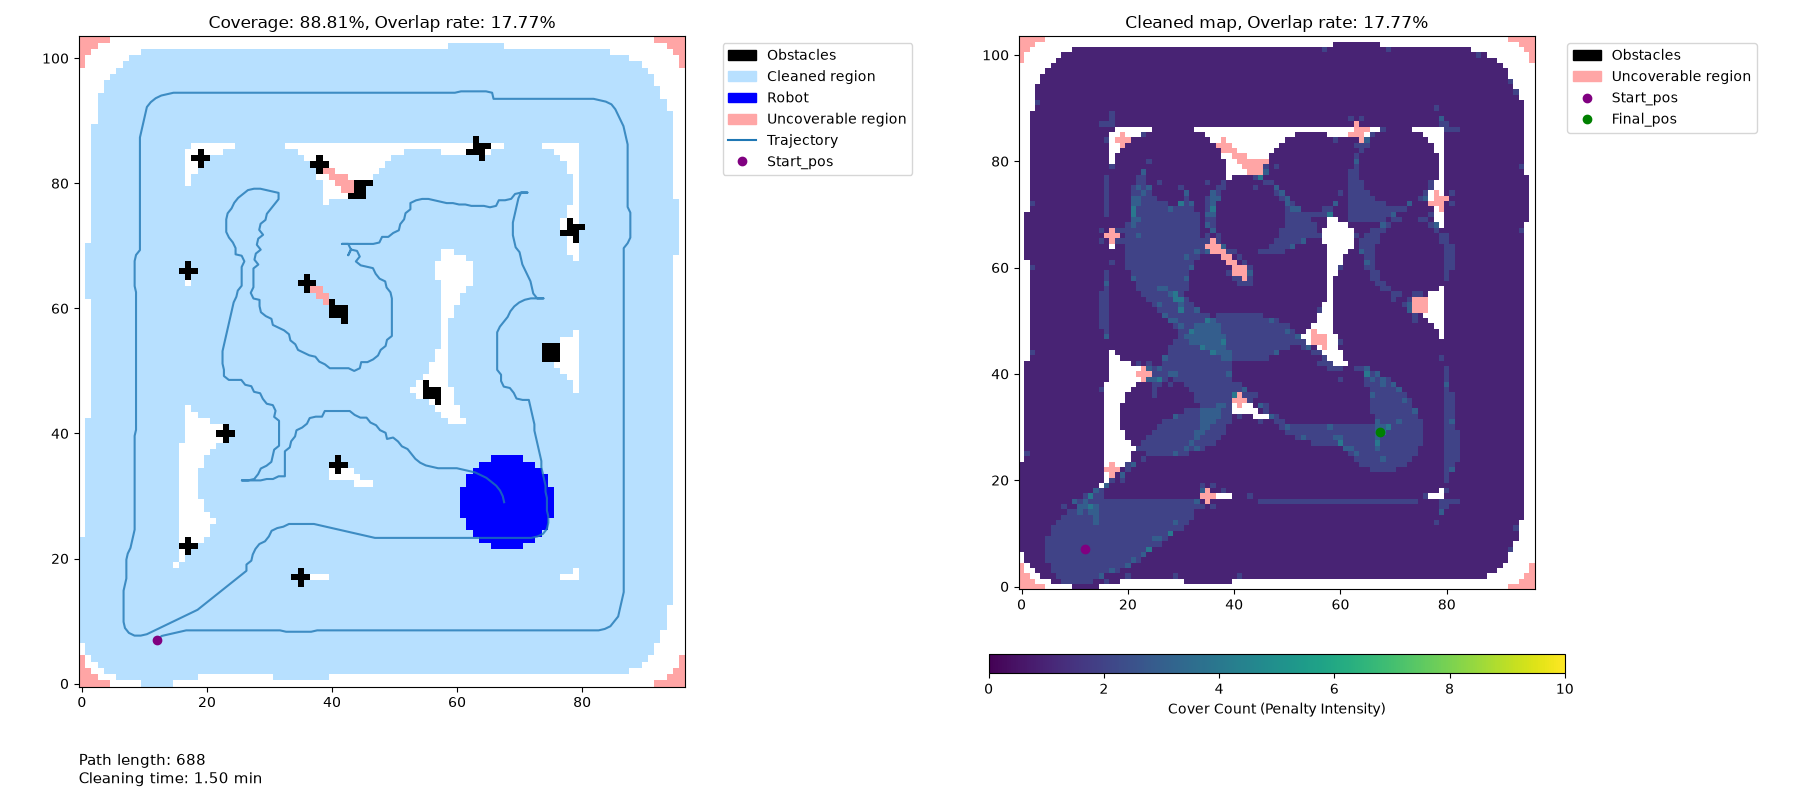

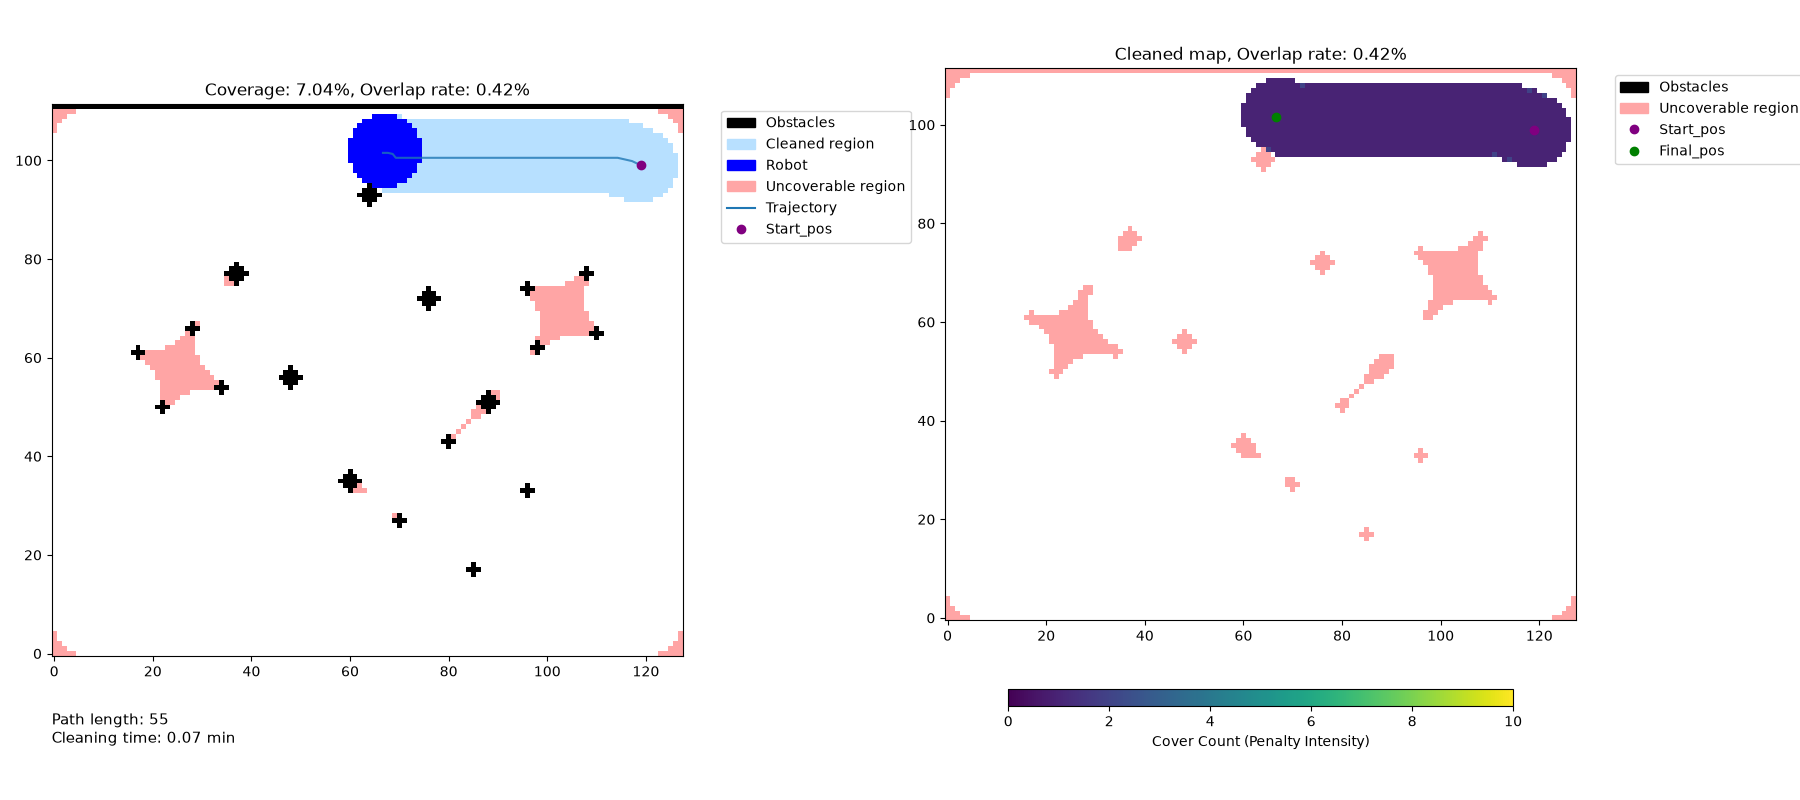

--------------------------------------------------
 ▶ Map Condition: Level 2 (Total tests: 250)
    - Coverage:     58.08% ± 19.86%
    - Overlap Rate: 12.38% ± 7.34%
    - Cleaning Time: 1.13 min ± 0.55 min
--------------------------------------------------
[Best Path]  Map name: test_map_L2_0236.npy | Cov: 90.1%, Overlap: 16.9%, Time: 2.6m
[Worst Path] Map name: test_map_L2_0069.npy | Cov: 6.8%, Overlap: 21.5%, Time: 0.2m


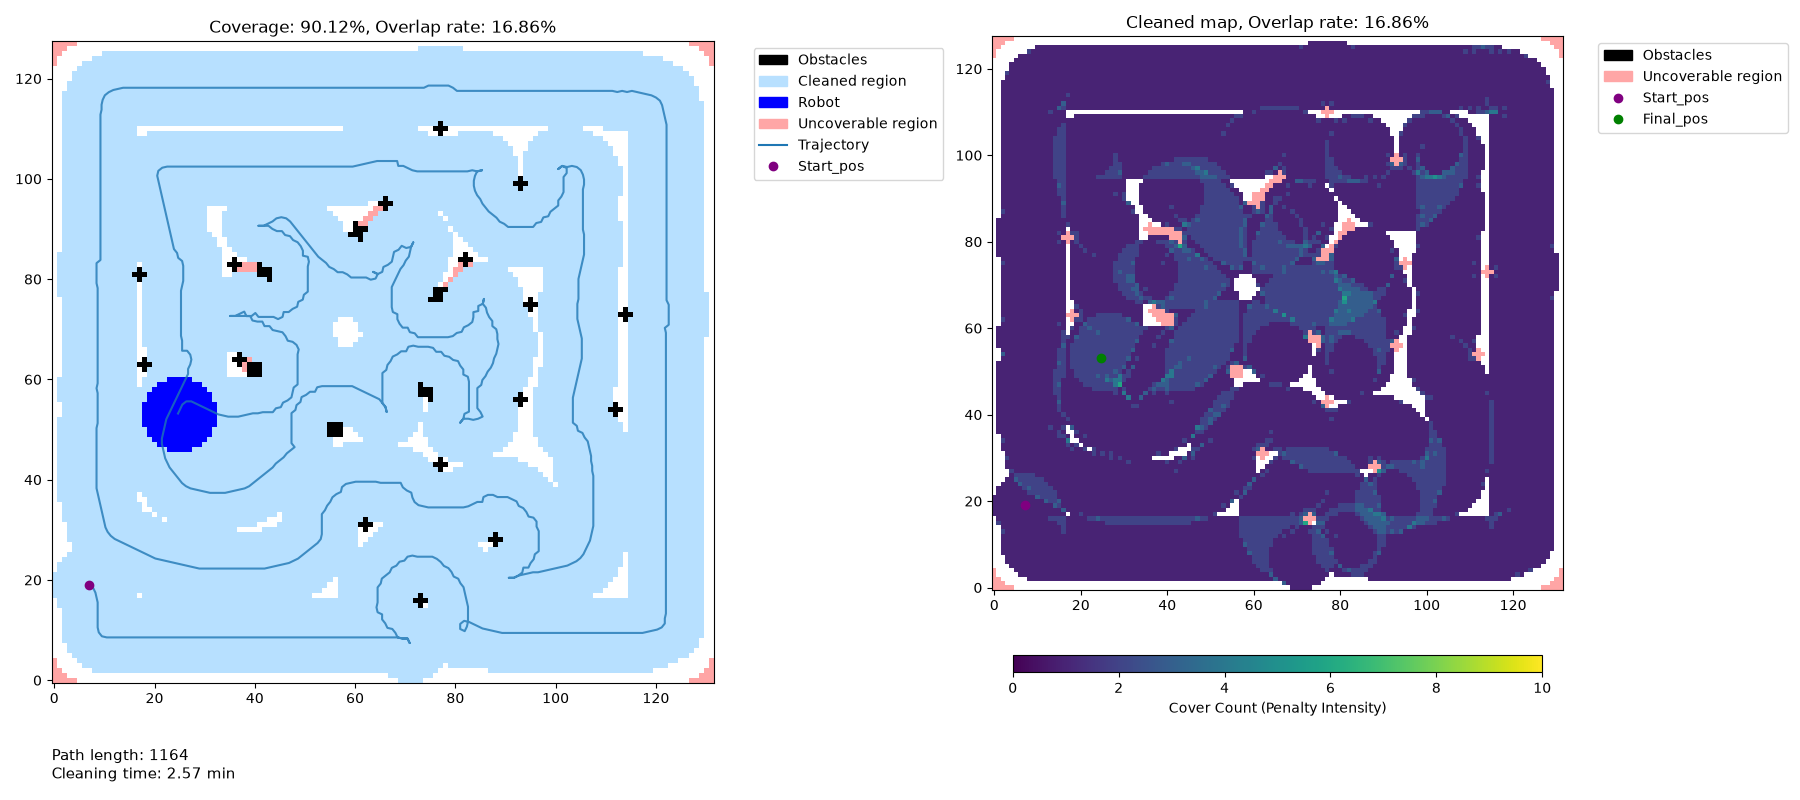

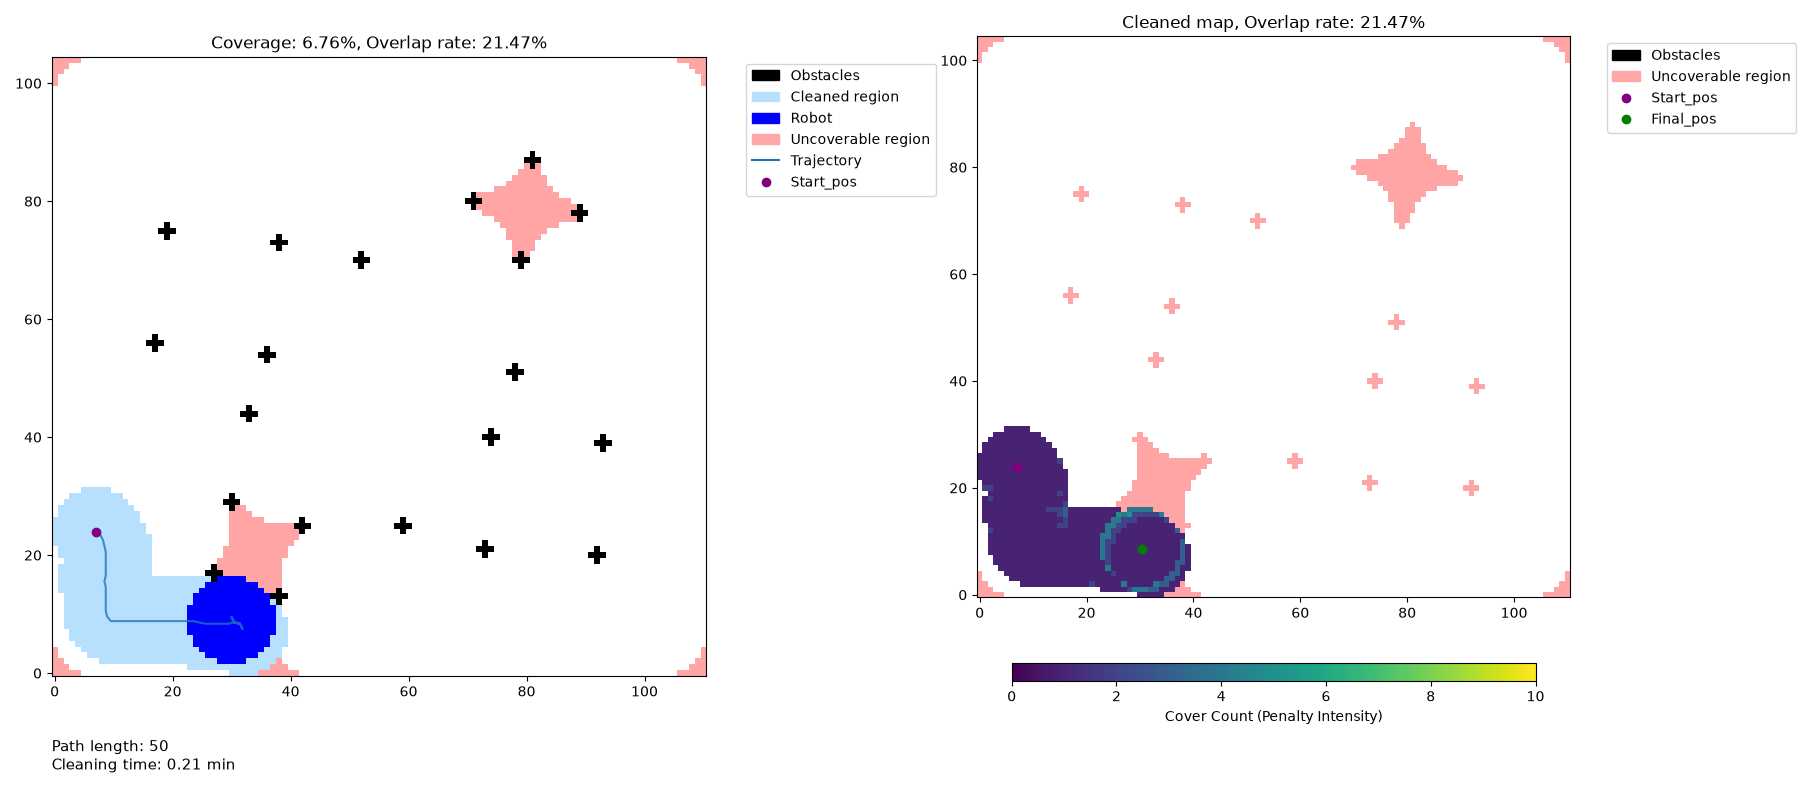

--------------------------------------------------
 ▶ Map Condition: Level 3 (Total tests: 250)
    - Coverage:     49.39% ± 20.58%
    - Overlap Rate: 12.09% ± 8.27%
    - Cleaning Time: 1.13 min ± 0.63 min
--------------------------------------------------
[Best Path]  Map name: test_map_L3_0072.npy | Cov: 86.7%, Overlap: 25.0%, Time: 2.4m
[Worst Path] Map name: test_map_L3_0189.npy | Cov: 3.7%, Overlap: 0.4%, Time: 0.0m


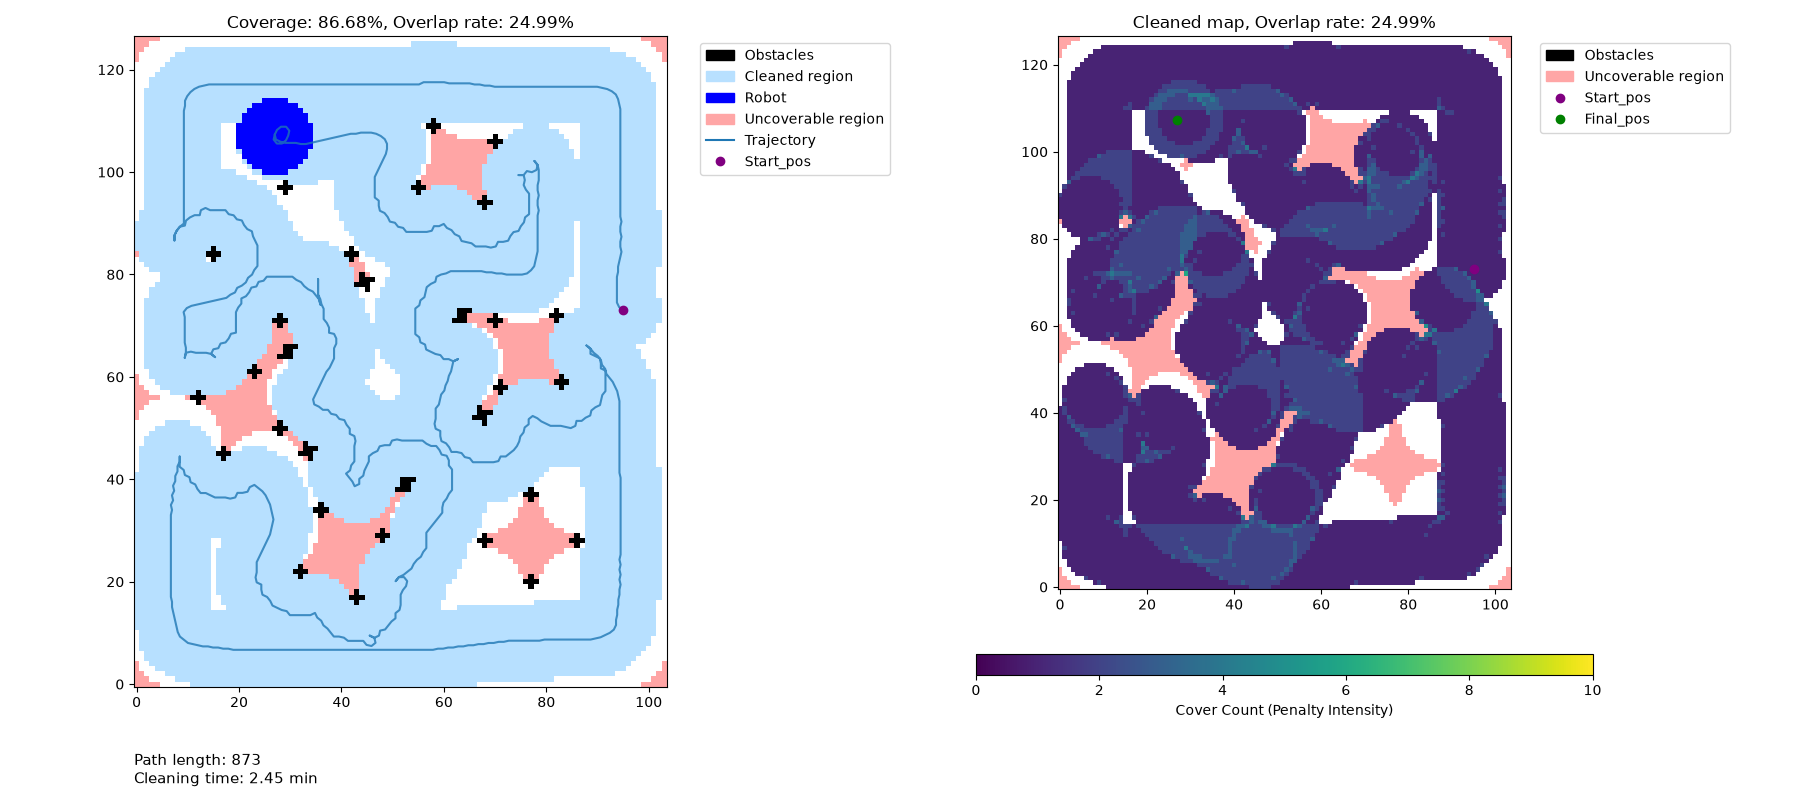

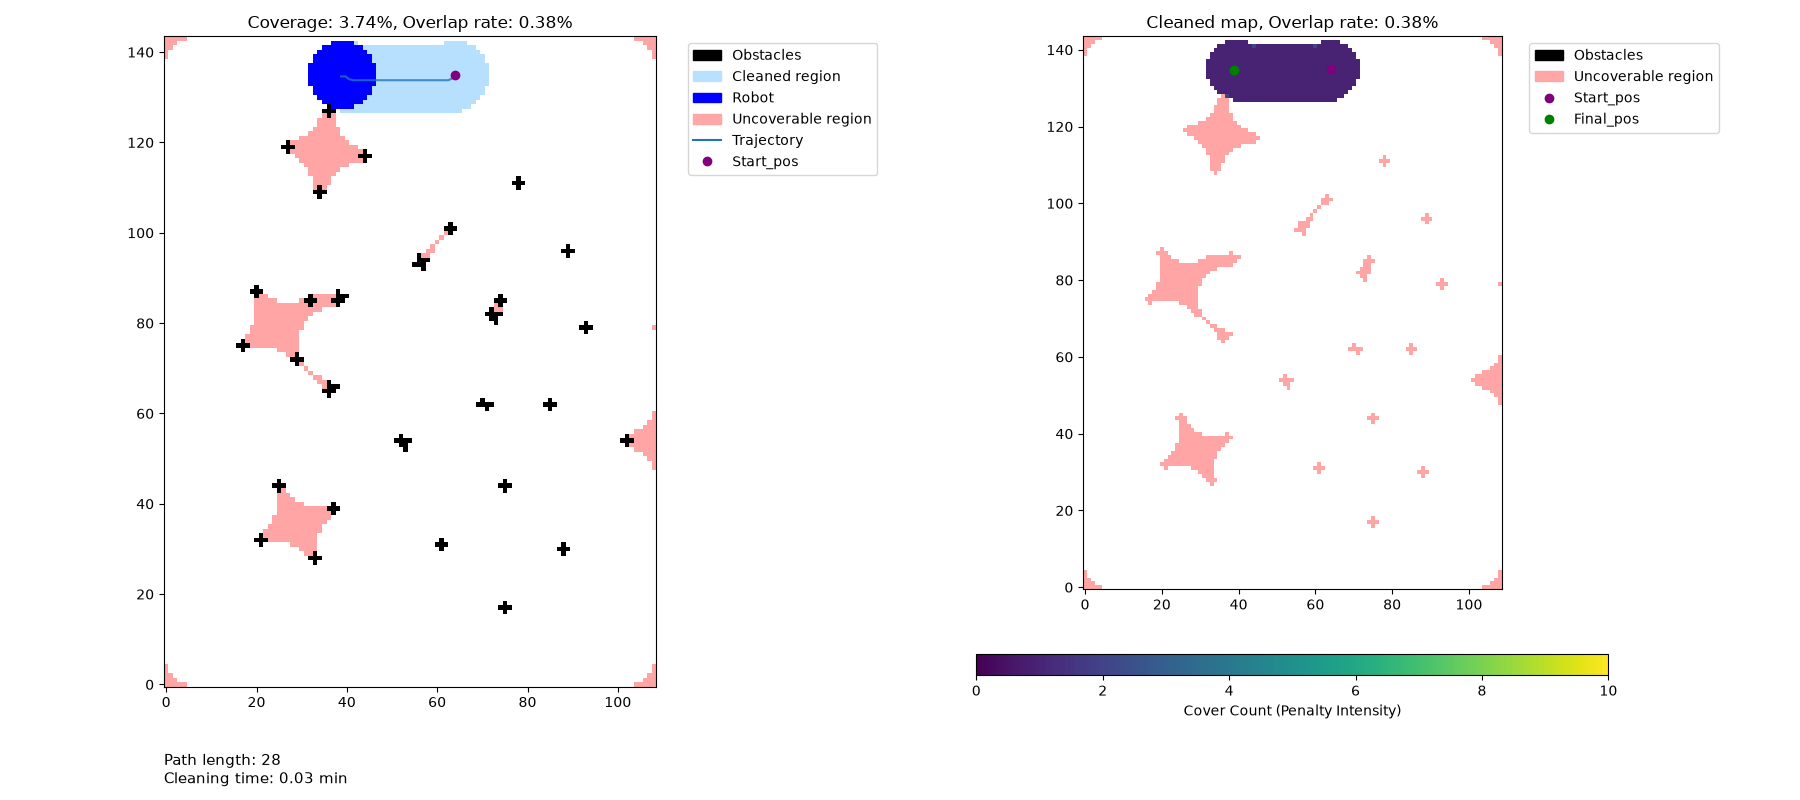

--------------------------------------------------
 ▶ Map Condition: Level 4 (Total tests: 247)
    - Coverage:     41.85% ± 22.12%
    - Overlap Rate: 12.57% ± 9.02%
    - Cleaning Time: 1.11 min ± 0.69 min
--------------------------------------------------
[Best Path]  Map name: test_map_L4_0126.npy | Cov: 85.7%, Overlap: 17.0%, Time: 2.3m
[Worst Path] Map name: test_map_L4_0230.npy | Cov: 4.3%, Overlap: 2.6%, Time: 0.1m


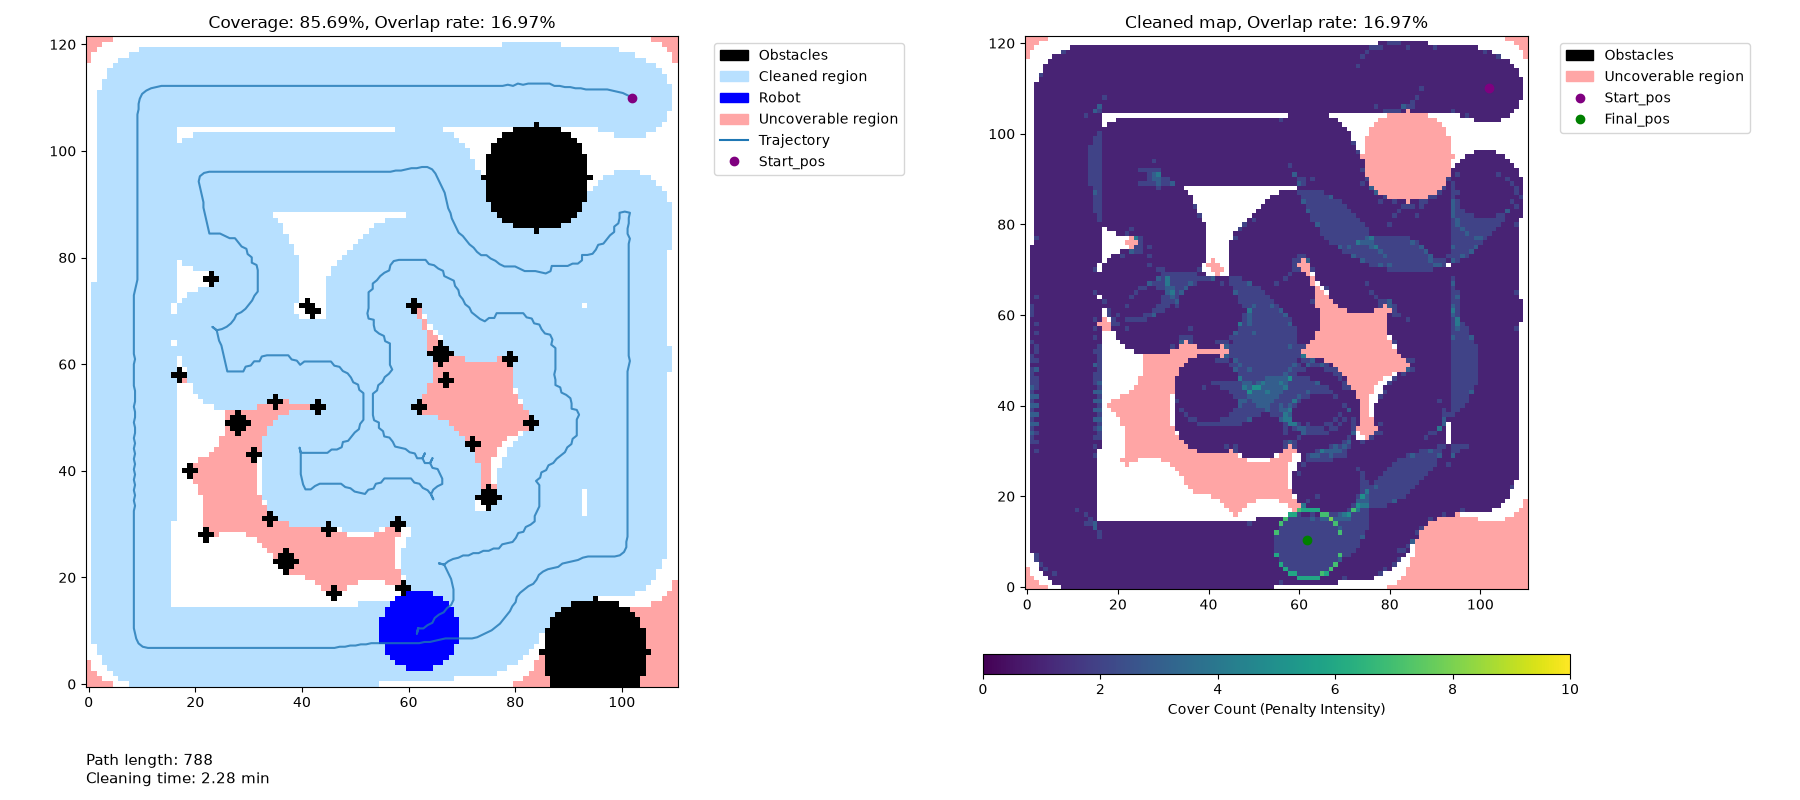

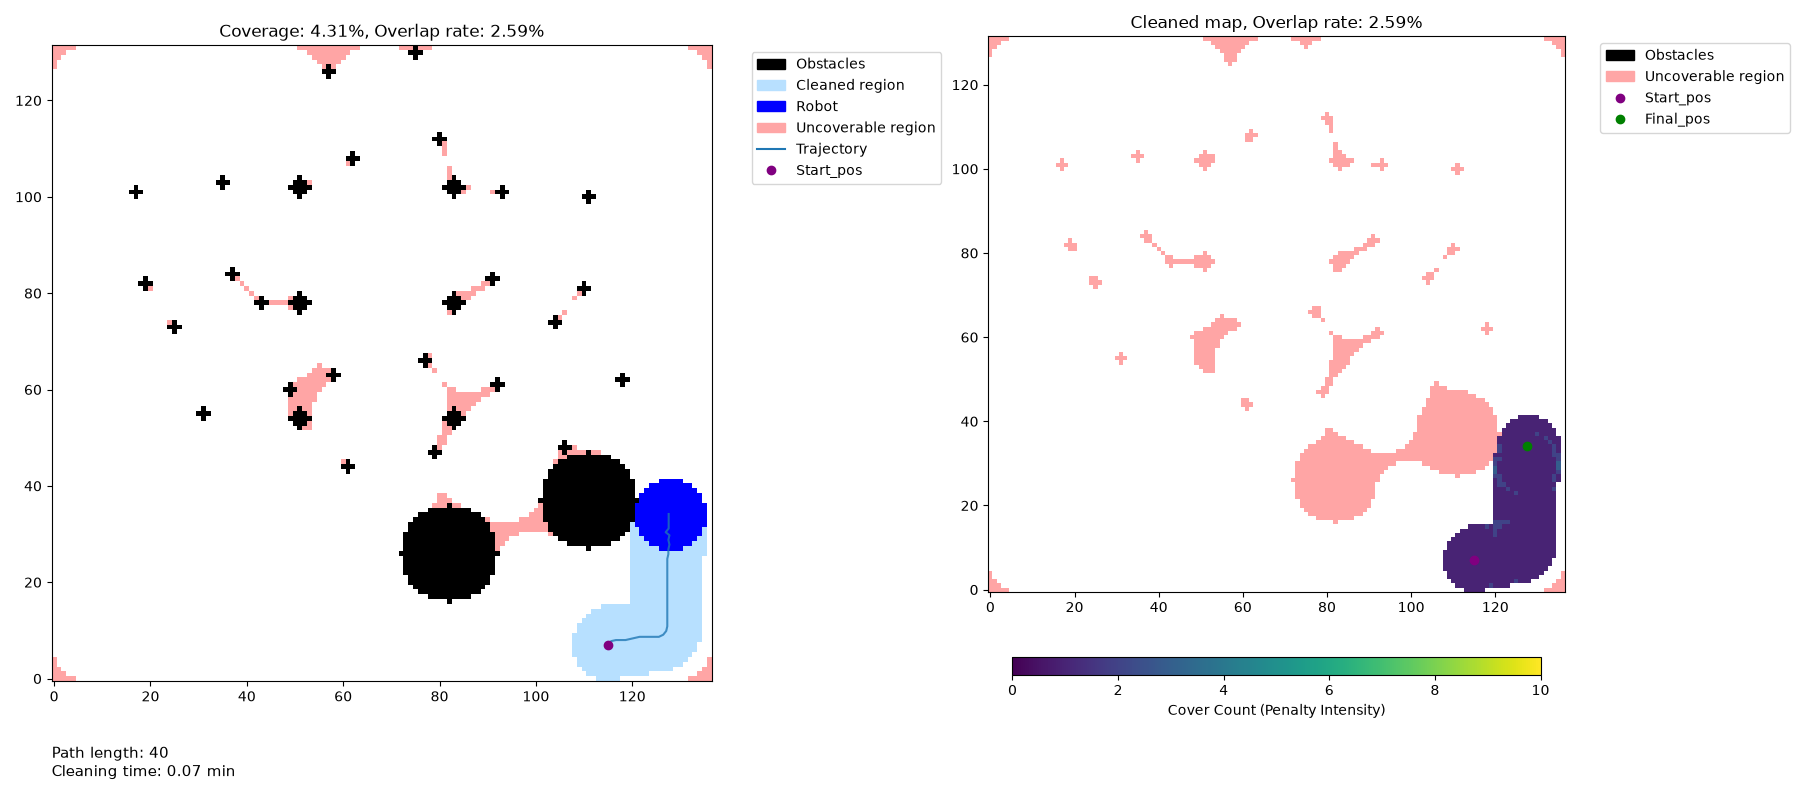

--------------------------------------------------

[Overall Test result]
    Coverage mean: 53.13%
    Cleaning time mean: 1.12 min
    Overlap rate mean: 12.36%
    Average computation time per map: 0.90 s


In [1]:
%cd c:\Users\wrlat\Desktop\LCH\LG_robot_DQN

from path_planner.main import main
import sys

args_str = """
    --mode test
    --model_name LSTM_model_change_to_advantage_and_reduce_steps.pth
    --optimizer adam
    --batch_size 32
    --lr 1e-5
    --momentum 0.9
    --valid_freq 5
    --ckp_freq 5
    --valid_map_num 5
    --valid_start_point_num 1
    --test_start_point_num 1
    --max_episodes 30000
    --max_steps 1500
    --max_step_per_eps 20
    --max_eps_per_map_size 100
    --use_train_maps
    --use_wandb
"""

sys.argv = [" "] + args_str.split()

# Training
main()

c:\Users\wrlat\Desktop\LCH\LG_robot_DQN
------------------------------
  [System Configuration]
  > Device: CUDA
  > GPU Name: NVIDIA GeForce RTX 4070 SUPER
  > VRAM: 12.88 GB
------------------------------
Test model loaded: src/path_planner/path_planner/models\LSTM_model_change_to_advantage_and_reduce_steps.pth
There is 1000 map files for testing.
Can't reset map file: test_map_L4_0200.npy
Can't reset map file: test_map_L4_0205.npy
Can't reset map file: test_map_L4_0220.npy

📊 [Test Results Breakdown by Map Conditions]
 ▶ Map Condition: Level 1 (Total tests: 250)
    - Coverage:     70.23% ± 16.35%
    - Overlap Rate: 24.10% ± 11.41%
    - Cleaning Time: 1.72 min ± 0.59 min
--------------------------------------------------
[Best Path]  Map name: test_map_L1_0046.npy | Cov: 90.4%, Overlap: 36.5%, Time: 2.0m
[Worst Path] Map name: test_map_L1_0190.npy | Cov: 11.0%, Overlap: 46.8%, Time: 0.6m


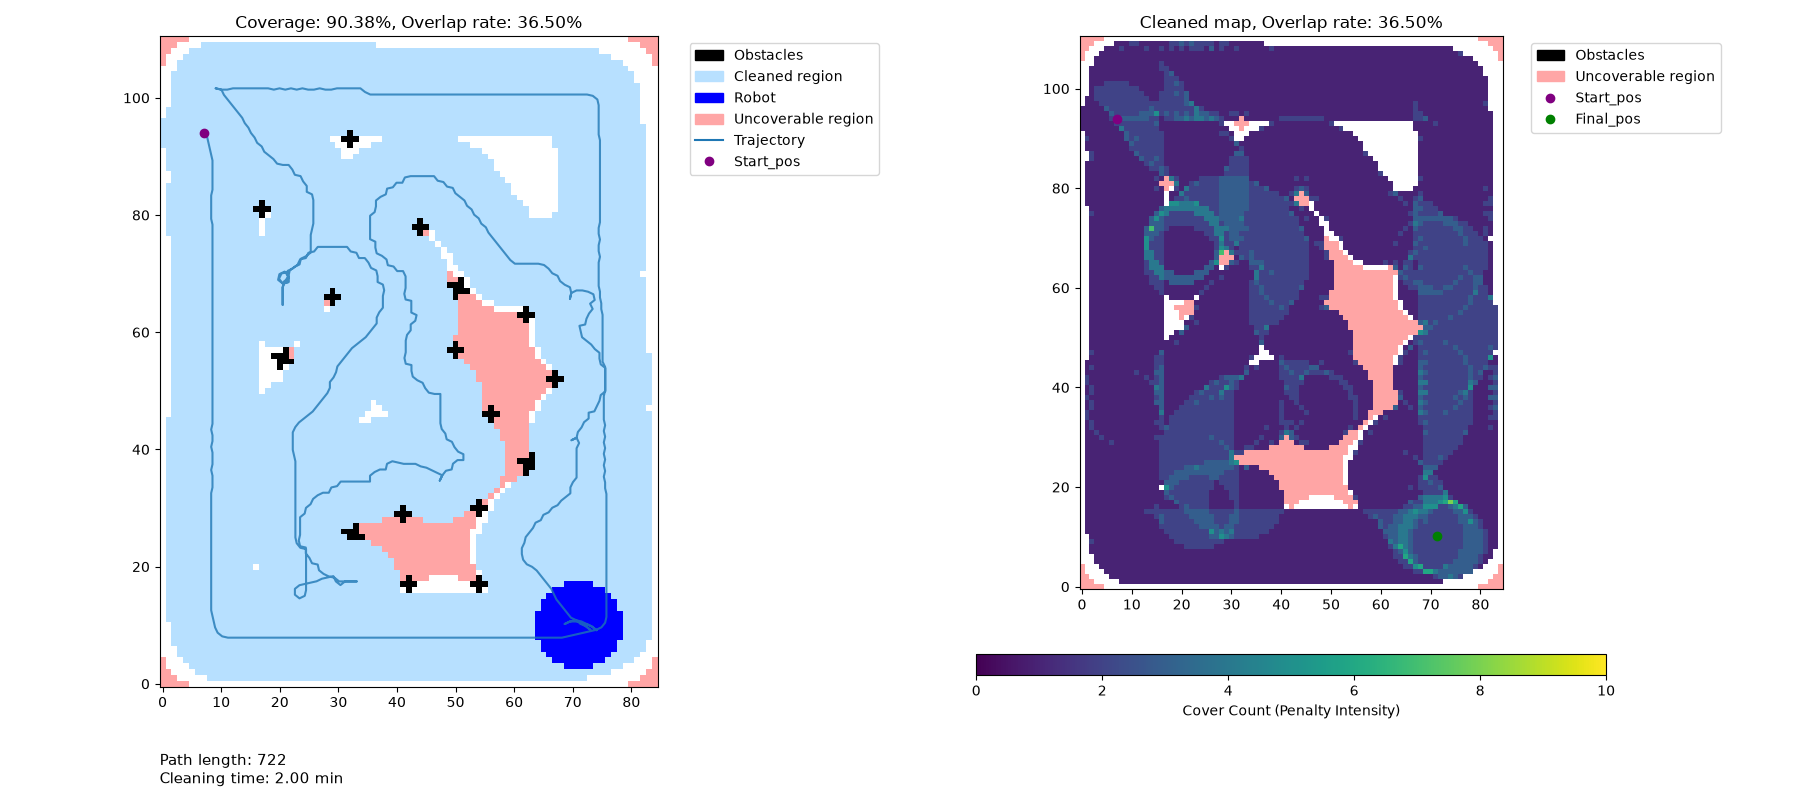

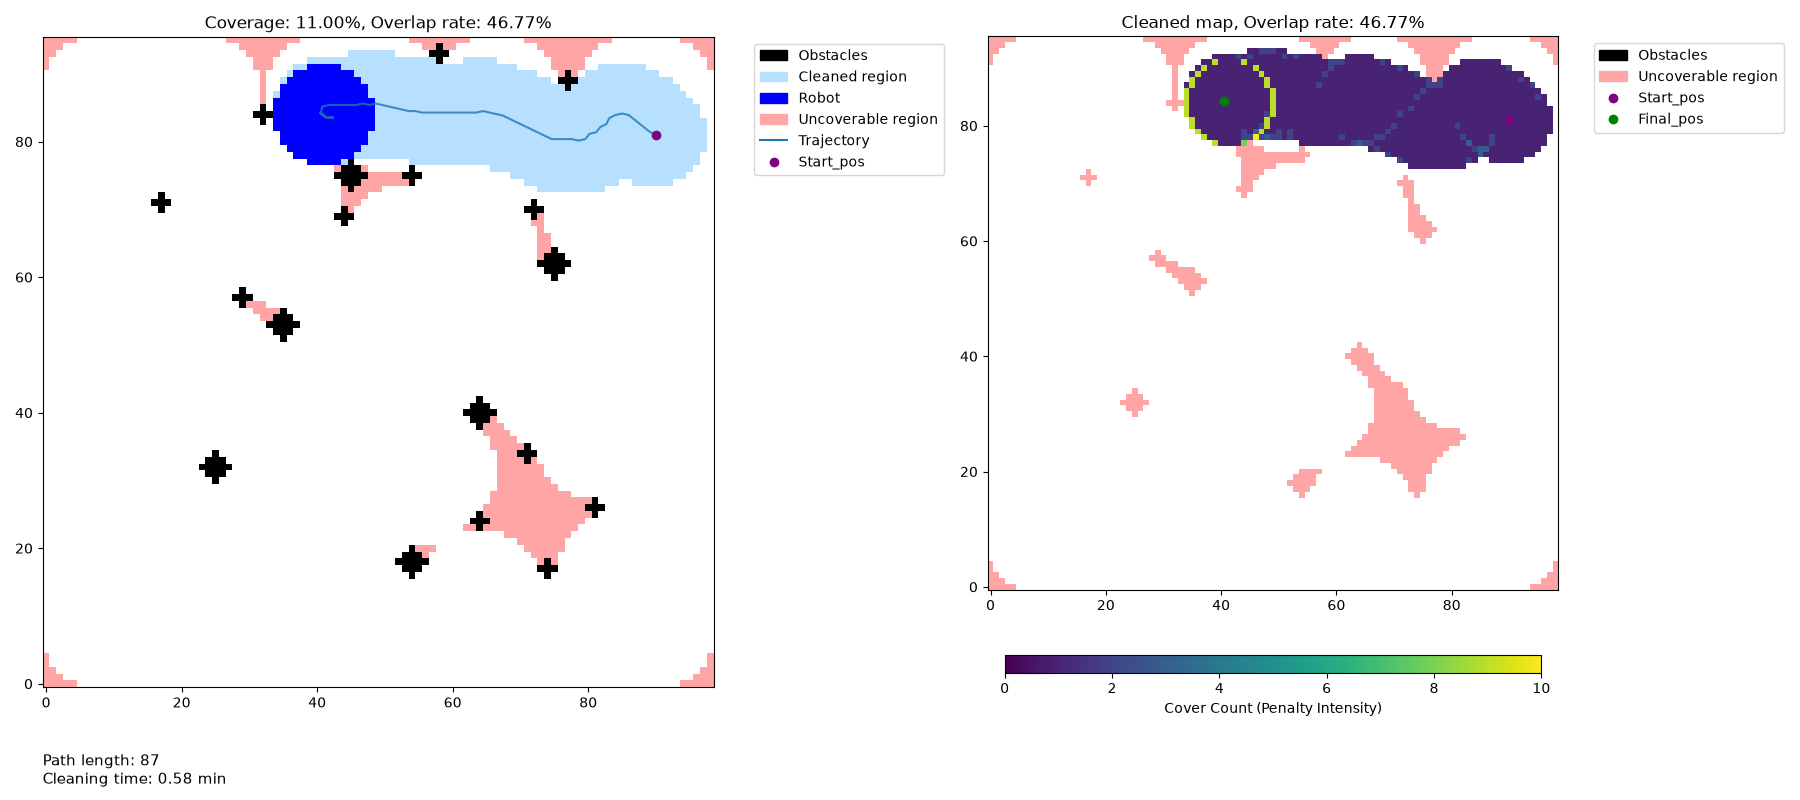

--------------------------------------------------
 ▶ Map Condition: Level 2 (Total tests: 250)
    - Coverage:     66.97% ± 20.00%
    - Overlap Rate: 24.94% ± 12.58%
    - Cleaning Time: 1.90 min ± 0.79 min
--------------------------------------------------
[Best Path]  Map name: test_map_L2_0236.npy | Cov: 90.1%, Overlap: 18.8%, Time: 2.6m
[Worst Path] Map name: test_map_L2_0069.npy | Cov: 6.8%, Overlap: 62.3%, Time: 0.5m


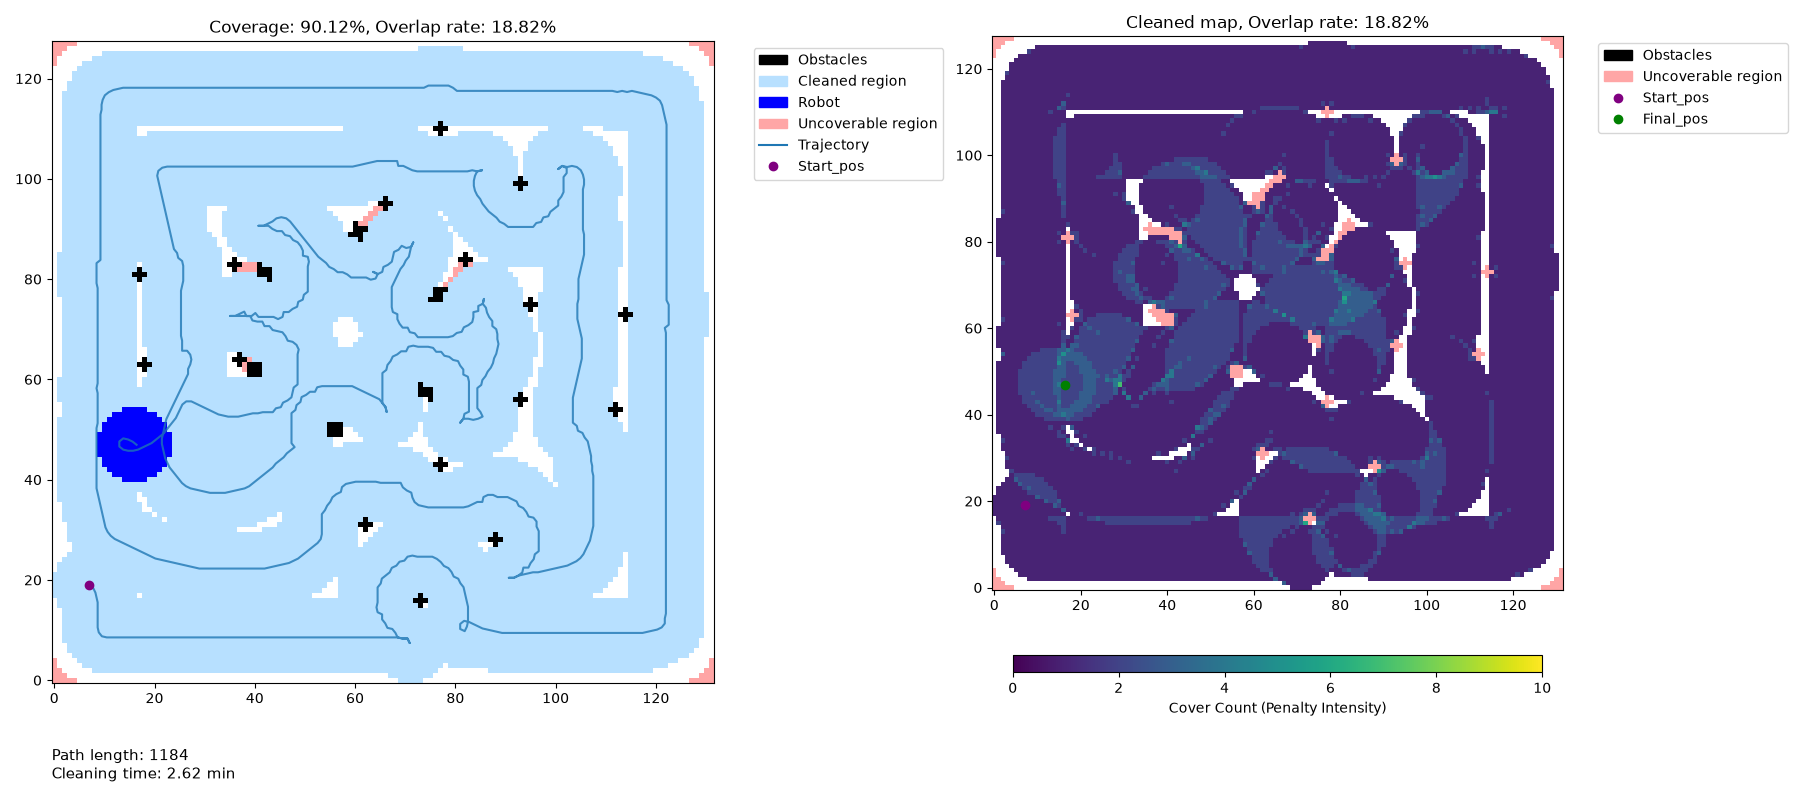

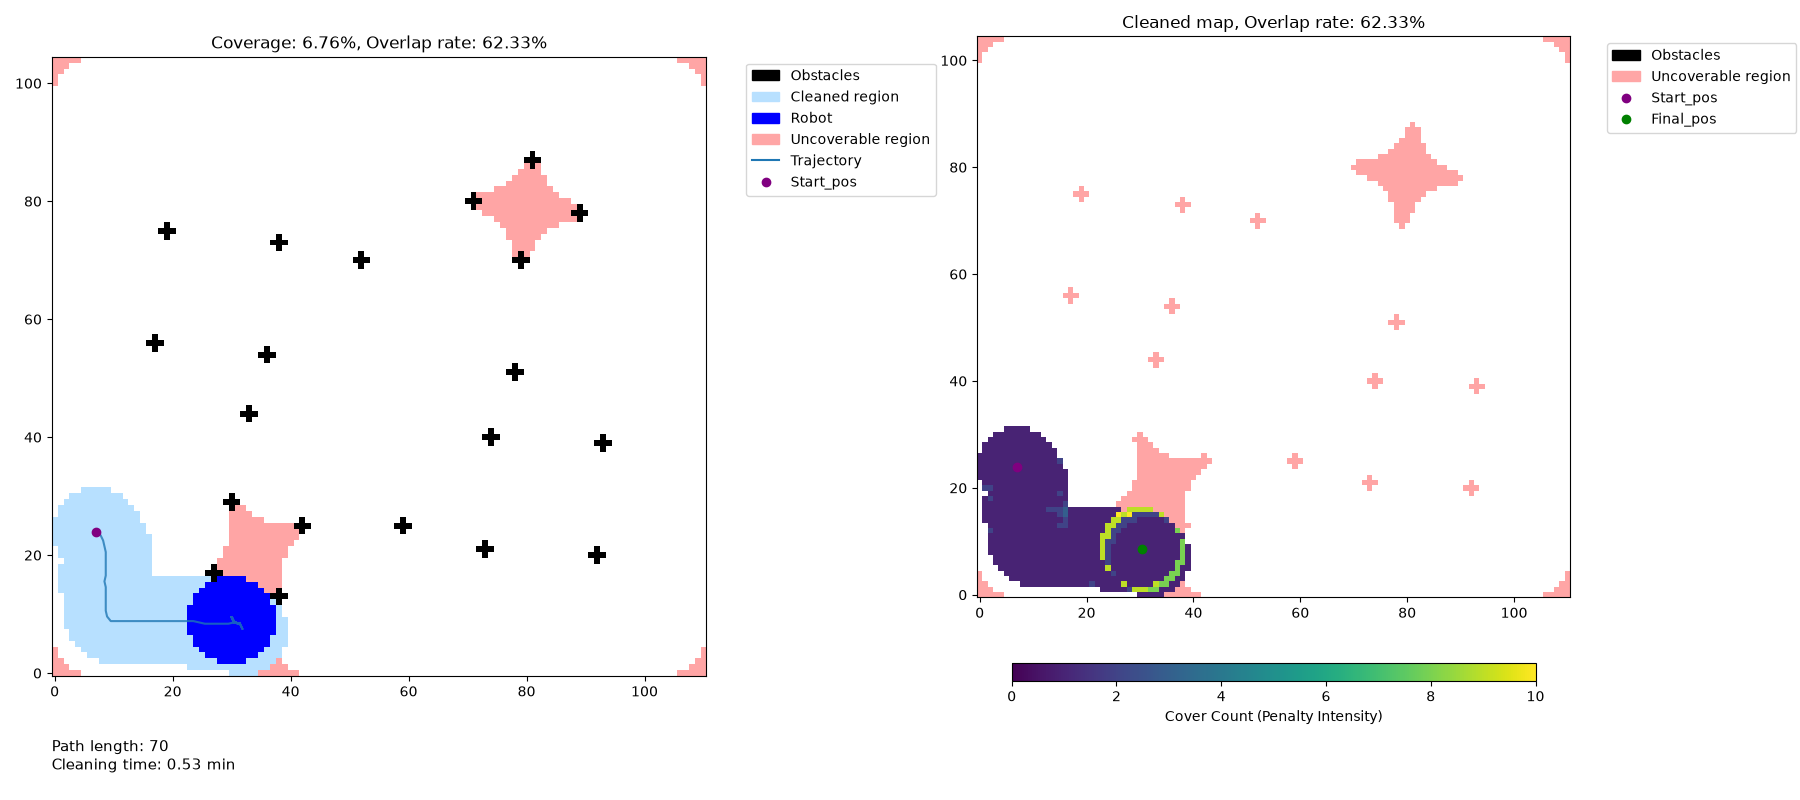

--------------------------------------------------
 ▶ Map Condition: Level 3 (Total tests: 250)
    - Coverage:     57.22% ± 21.29%
    - Overlap Rate: 21.89% ± 12.78%
    - Cleaning Time: 1.82 min ± 0.88 min
--------------------------------------------------
[Best Path]  Map name: test_map_L3_0013.npy | Cov: 92.1%, Overlap: 52.9%, Time: 2.4m
[Worst Path] Map name: test_map_L3_0106.npy | Cov: 5.9%, Overlap: 70.0%, Time: 0.3m


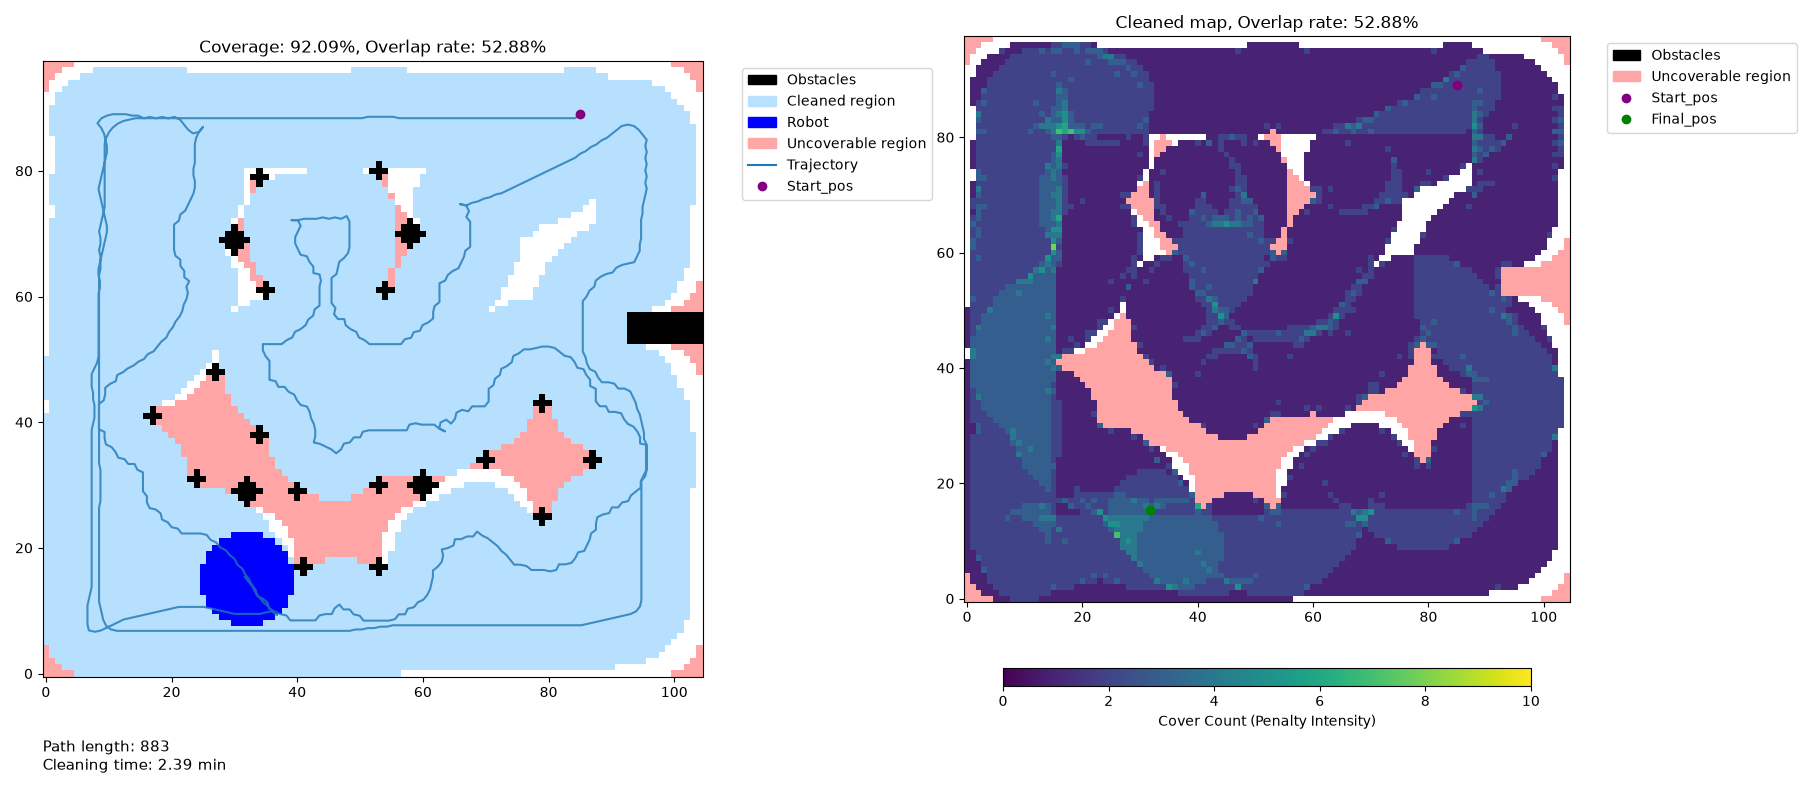

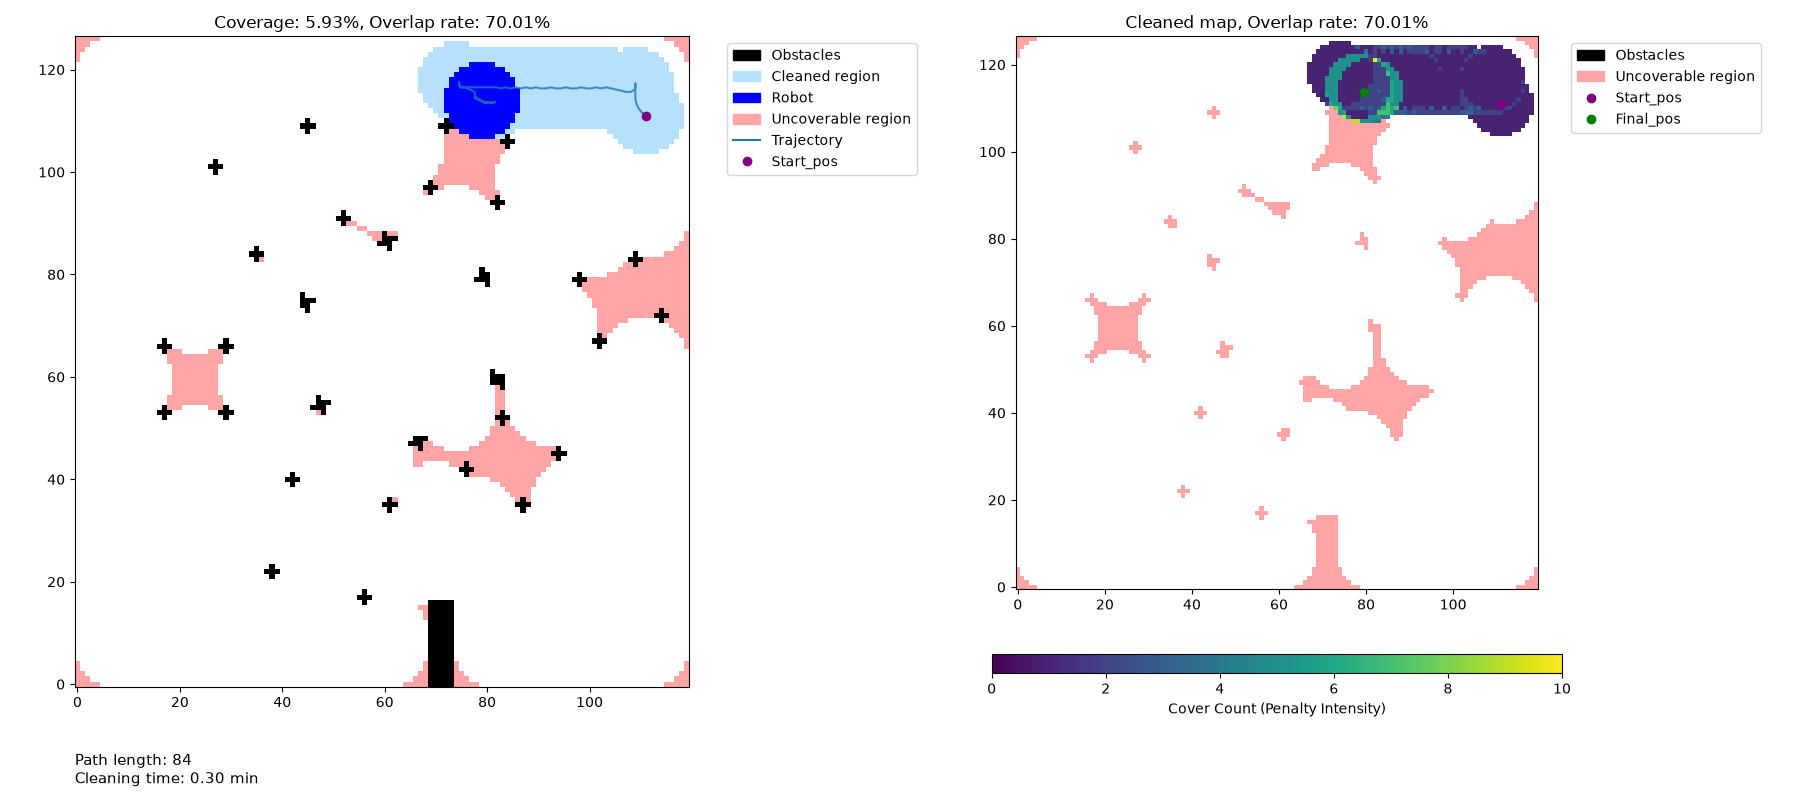

--------------------------------------------------
 ▶ Map Condition: Level 4 (Total tests: 247)
    - Coverage:     47.48% ± 23.35%
    - Overlap Rate: 23.11% ± 13.85%
    - Cleaning Time: 1.73 min ± 0.81 min
--------------------------------------------------
[Best Path]  Map name: test_map_L4_0129.npy | Cov: 91.0%, Overlap: 44.4%, Time: 3.1m
[Worst Path] Map name: test_map_L4_0188.npy | Cov: 4.9%, Overlap: 97.3%, Time: 0.5m


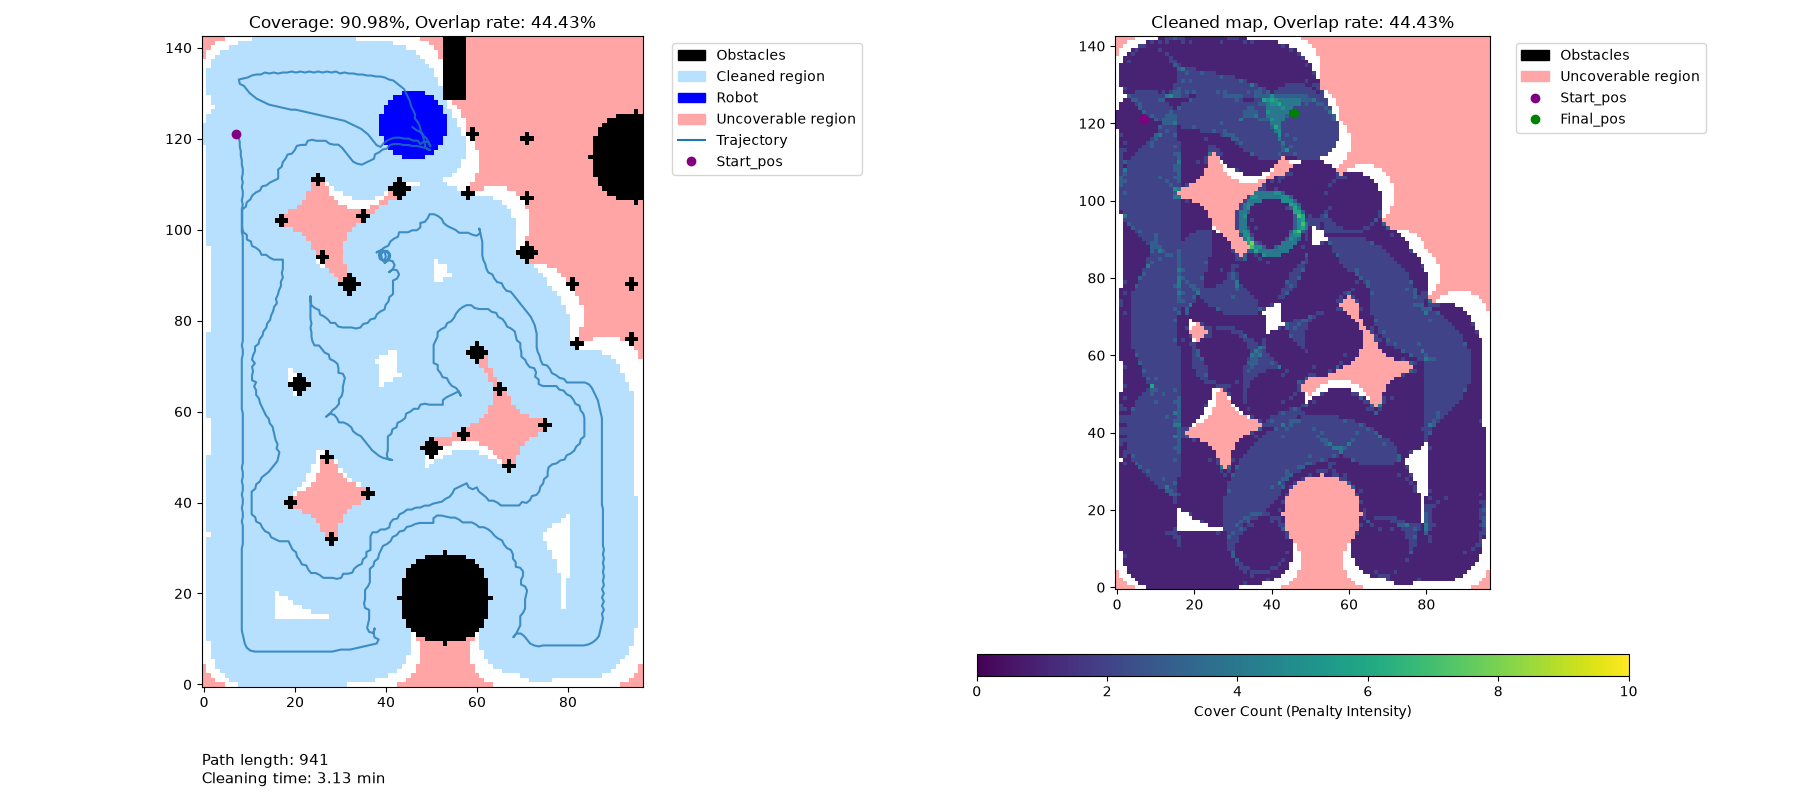

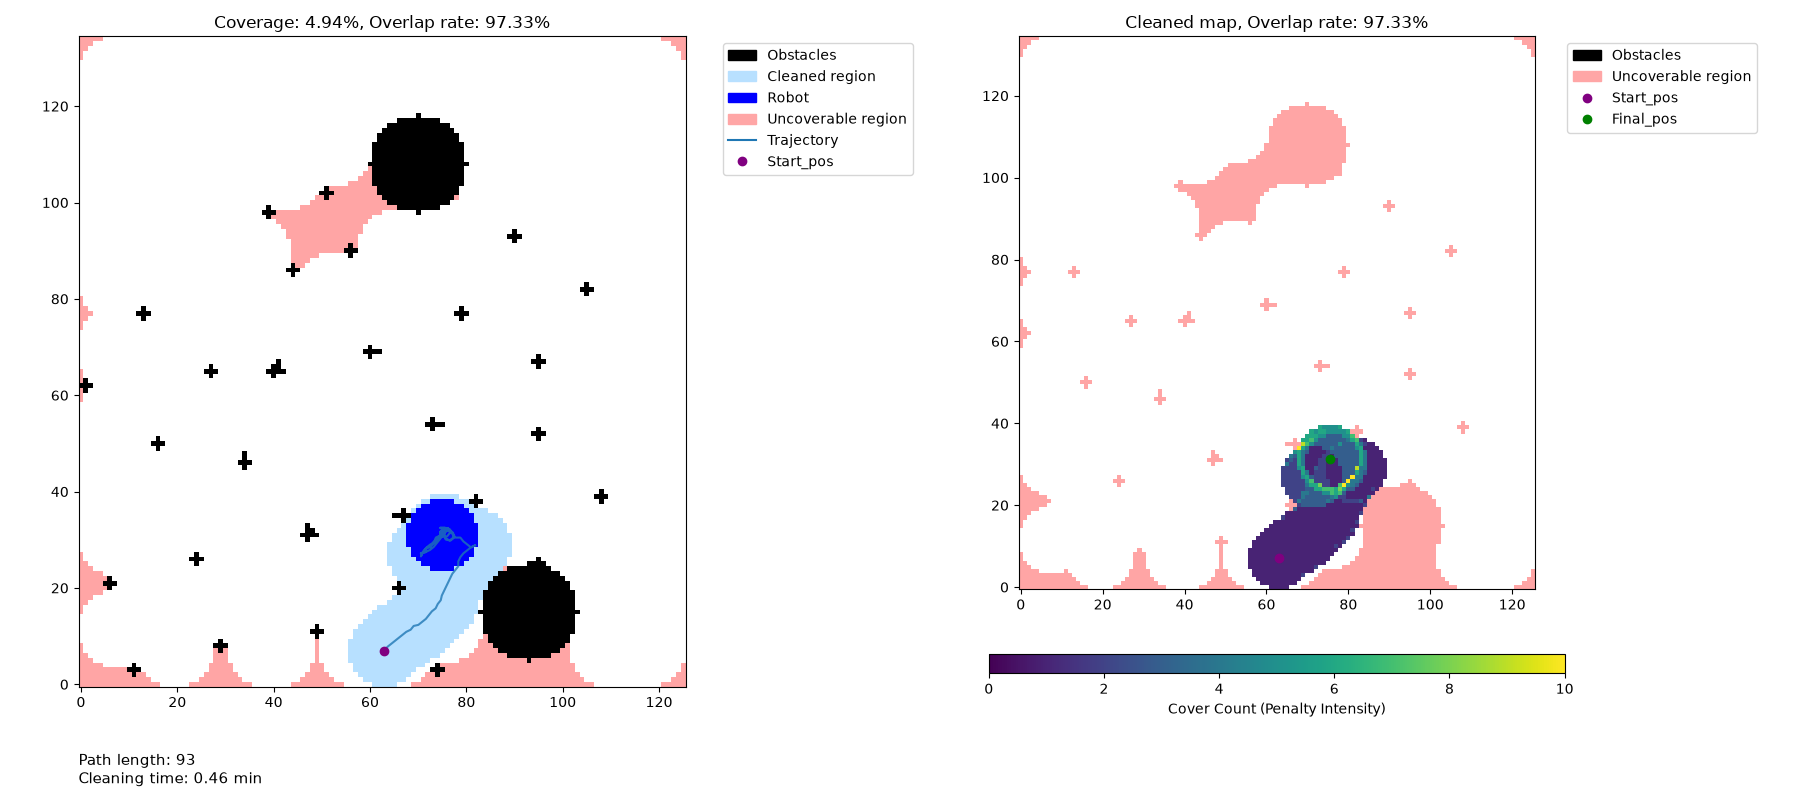

--------------------------------------------------

[Overall Test result]
    Coverage mean: 60.52%
    Cleaning time mean: 1.79 min
    Overlap rate mean: 23.51%
    Average computation time per map: 1.64 s


In [2]:
%cd c:\Users\wrlat\Desktop\LCH\LG_robot_DQN

from path_planner.main import main
import sys

args_str = """
    --mode test
    --model_name LSTM_model_change_to_advantage_and_reduce_steps.pth
    --optimizer adam
    --batch_size 32
    --lr 1e-5
    --momentum 0.9
    --valid_freq 5
    --ckp_freq 5
    --valid_map_num 5
    --valid_start_point_num 1
    --test_start_point_num 1
    --max_episodes 30000
    --max_steps 1500
    --max_step_per_eps 20
    --max_eps_per_map_size 100
    --use_train_maps
    --use_wandb
"""

sys.argv = [" "] + args_str.split()

# Training
main()

In [2]:
%cd c:\Users\wrlat\Desktop\LCH\LG_robot_DQN

from path_planner.main import main
import sys

args_str = """
    --mode train
    --model_name LSTM_model_change_train_maps.pth
    --optimizer adam
    --batch_size 32
    --lr 1e-5
    --momentum 0.9
    --valid_freq 5
    --ckp_freq 5
    --valid_map_num 5
    --valid_start_point_num 1
    --test_start_point_num 1
    --max_episodes 30000
    --max_steps 1500
    --max_step_per_eps 20
    --max_eps_per_map_size 100
    --use_train_maps
    --use_wandb
"""

sys.argv = [" "] + args_str.split()

# Training
main()

c:\Users\wrlat\Desktop\LCH\LG_robot_DQN
------------------------------
  [System Configuration]
  > Device: CUDA
  > GPU Name: NVIDIA GeForce RTX 4070 SUPER
  > VRAM: 12.88 GB
------------------------------


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\wrlat\_netrc.
wandb: Currently logged in as: poiuy45987 (lg-robot-cleaner) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


No checkpoint files found!
[Episode 1] Starting training...
	Episode reward: 0.25009846687316895
[Episode 2] Starting training...
	Episode reward: 0.33912476897239685
[Episode 3] Starting training...
	Episode reward: 0.3232041597366333
[Episode 4] Starting training...
	Episode reward: 0.28509026765823364
[Episode 5] Starting training...
	Episode reward: 0.2625257670879364
Validation...
Failed to reset environment after 100 attempts.
Map config: MapConfigSchema(file_path=None, level=4, H=40, W=40)
[Validation] Episode 5: 
	Coverage Mean = 65.74%
	Overlap Rate Mean = 80.87%
	Cleaning Time Mean = 0.96 min
[Episode 6] Starting training...
	Episode reward: 0.23879021406173706
[Episode 7] Starting training...
	Episode reward: 0.21391230821609497
[Episode 8] Starting training...
	Episode reward: 0.3470691442489624
[Episode 9] Starting training...
	Episode reward: 0.3198974132537842
[Episode 10] Starting training...
	Episode reward: 0.33381038904190063
Validation...
[Validation] Episode 10: 
	

KeyboardInterrupt: 

In [1]:
%cd c:\Users\wrlat\Desktop\LCH\LG_robot_DQN

from path_planner.main import main
import sys

args_str = """
    --mode train
    --pre_model_name LSTM_model_change_to_advantage_and_reduce_steps.pth
    --model_name LSTM_model_use_pre_train.pth
    --optimizer adam
    --batch_size 32
    --lr 1e-5
    --momentum 0.9
    --valid_freq 5
    --ckp_freq 5
    --valid_map_num 5
    --valid_start_point_num 1
    --test_start_point_num 1
    --max_episodes 30000
    --max_steps 1500
    --max_step_per_eps 20
    --max_eps_per_map_size 100
    --use_train_maps
    --use_wandb
"""

sys.argv = [" "] + args_str.split()

# Training
main()

c:\Users\wrlat\Desktop\LCH\LG_robot_DQN
------------------------------
  [System Configuration]
  > Device: CUDA
  > GPU Name: NVIDIA GeForce RTX 4070 SUPER
  > VRAM: 12.88 GB
------------------------------


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\wrlat\_netrc.
wandb: Currently logged in as: poiuy45987 (lg-robot-cleaner) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Use pre-trained model...
Loading pre-trained model: src/path_planner/path_planner/models\LSTM_model_change_to_advantage_and_reduce_steps.pth
[Initial map size] 120x120.
[Episode 1] Starting training...
	Episode reward: 0.4408690333366394
[Episode 2] Starting training...


c:\Users\wrlat\miniconda3\envs\lgrobot_lch\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Error detected in MulBackward0. Traceback of forward call that caused the error:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\wrlat\miniconda3\envs\lgrobot_lch\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\wrlat\miniconda3\envs\lgrobot_lch\Lib\site-packages\traitlets\config\application.py", line 1082, in launch_instance
    app.start()
  File "c:\Users\wrlat\miniconda3\envs\lgrobot_lch\Lib\site-packages\ipykernel\kernelapp.py", line 807, in start
    self.io_loop.start()
  File "c:\Users\wrlat\miniconda3\envs\lgrobot_lch\Lib\site-packages\tornado\platform\asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "c:\Users\wrlat\miniconda3\envs\lgrobot_lch\Lib\asyncio\base_events.py", line 645, in run_forever
    self._run_once()


RuntimeError: Function 'MulBackward0' returned nan values in its 0th output.